# Unemployment Analysis with Python

## Oasis Infobyte Internship — Task 2

**Name:** Himanshu Chavda  
**Track:** Data Science  
**Task:** Unemployment Analysis with Python

---

## Objective

The objective of this project is to perform exploratory data analysis on unemployment data in India.

The analysis focuses on:

- Regional unemployment patterns
- Temporal unemployment trends
- Employment levels
- Labour participation rates
- Urban and rural unemployment differences
- Correlation between key employment indicators
- Changes in unemployment before and after the COVID-19 period

The project uses Python-based data analysis and visualization techniques to identify meaningful patterns and insights from the dataset.

# 1. Import Required Libraries

The following Python libraries are used for data manipulation, statistical analysis, and visualization.

In [2208]:
# ============================================================
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully!")

Libraries imported successfully!


# 2. Load Dataset

The unemployment dataset is loaded from the project's `data` directory.

The dataset contains regional and monthly information related to unemployment, employment, and labour participation in India.

In [2209]:
file_path = "../data/unemployment_in_india.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

Dataset loaded successfully.
Rows    : 768
Columns : 7


# 3. Dataset Overview

Before performing analysis, we inspect the structure, dimensions, column names, and data types of the dataset.

In [2210]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(768, 7)


In [2211]:
print("Column Names:")
print(df.columns.tolist())

Column Names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']


In [2212]:
print("Data Types:")
df.dtypes

Data Types:


Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

In [2213]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [2214]:
print("First 5 Records:")
display(df.head())

First 5 Records:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,"11,999,139.00",43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,"11,755,881.00",42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,"12,086,707.00",43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,"12,285,693.00",43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,"12,256,762.00",44.68,Rural


In [2215]:
print("Last 5 Records:")
display(df.tail())

Last 5 Records:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 4. Missing Value Analysis

Missing values can affect statistical calculations and machine learning models. Therefore, missing values are identified before performing further analysis.

In [2216]:
missing_values = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_summary)

,Missing Values,Missing Percentage
Region,28,3.65
Date,28,3.65
Frequency,28,3.65
Estimated Unemployment Rate (%),28,3.65
Estimated Employed,28,3.65
Estimated Labour Participation Rate (%),28,3.65
Area,28,3.65


# 5. Duplicate Record Analysis

Duplicate records can distort aggregate statistics. We therefore check the dataset for duplicate rows.

In [2217]:
duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count:,}")

Number of duplicate rows: 27


In [2218]:
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicate rows removed.")
else:
    print("No duplicate rows found.")

Duplicate rows removed.


# 6. Data Cleaning and Type Conversion

The dataset may contain unnecessary spaces in column names and text fields. These are cleaned before analysis.

The `Date` column is converted into datetime format so that time-based analysis can be performed correctly.

In [2219]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Remove unnecessary spaces from text columns
text_columns = df.select_dtypes(include="object").columns

for column in text_columns:
    df[column] = df[column].astype(str).str.strip()

In [2220]:
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

In [2221]:
print(df["Date"].dtype)

datetime64[ns]


In [2222]:
numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

In [2223]:
df[numeric_columns].dtypes

Estimated Unemployment Rate (%)            float64
Estimated Employed                         float64
Estimated Labour Participation Rate (%)    float64
dtype: object

# 7. Final Data Quality Check

After cleaning and type conversion, the dataset is checked again for missing values and invalid dates.

In [2224]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nInvalid Dates:")
print(df["Date"].isna().sum())

Dataset Shape: (741, 7)

Missing Values:


Region                                     0
Date                                       1
Frequency                                  0
Estimated Unemployment Rate (%)            1
Estimated Employed                         1
Estimated Labour Participation Rate (%)    1
Area                                       0
dtype: int64


Invalid Dates:
1


In [2225]:
df = df.dropna(
    subset=[
        "Date",
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
).reset_index(drop=True)

In [2226]:
print("Final Dataset Shape:", df.shape)

Final Dataset Shape: (740, 7)


# 8. Descriptive Statistics

Descriptive statistics provide an overview of the central tendency and spread of the major numerical variables.

In [2227]:
display(
    df[
        [
            "Estimated Unemployment Rate (%)",
            "Estimated Employed",
            "Estimated Labour Participation Rate (%)"
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Estimated Unemployment Rate (%),740.00,11.79,10.72,0.00,4.66,8.35,15.89,76.74
Estimated Employed,740.00,"7,204,460.03","8,087,988.43","49,420.00","1,190,404.50","4,744,178.50","11,275,489.50","45,777,509.00"
Estimated Labour Participation Rate (%),740.00,42.63,8.11,13.33,38.06,41.16,45.51,72.57


## 8.1 Analysis Period

Understanding the time period covered by the dataset is important for interpreting the COVID-19 analysis.

In [2228]:
print("Start Date:", df["Date"].min().date())
print("End Date  :", df["Date"].max().date())
print("Total Months:", df["Date"].dt.to_period("M").nunique())

Start Date: 2019-05-31
End Date  : 2020-06-30
Total Months: 14


# 9. Time-Based Feature Engineering

Additional time features are created to support monthly and yearly analysis.

In [2229]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%B")
df["Year_Month"] = df["Date"].dt.to_period("M").astype(str)

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Month_Name,Year_Month
0,Andhra Pradesh,2019-05-31,Monthly,3.65,"11,999,139.00",43.24,Rural,2019,5,May,2019-05
1,Andhra Pradesh,2019-06-30,Monthly,3.05,"11,755,881.00",42.05,Rural,2019,6,June,2019-06
2,Andhra Pradesh,2019-07-31,Monthly,3.75,"12,086,707.00",43.50,Rural,2019,7,July,2019-07
3,Andhra Pradesh,2019-08-31,Monthly,3.32,"12,285,693.00",43.97,Rural,2019,8,August,2019-08
4,Andhra Pradesh,2019-09-30,Monthly,5.17,"12,256,762.00",44.68,Rural,2019,9,September,2019-09


# Visualization Theme

A consistent dark visualization theme is applied throughout the analysis to create a clean, professional, and portfolio-ready presentation.

In [2230]:
# Create image output directory
os.makedirs("../images", exist_ok=True)

# ------------------------------------------
# Seaborn base theme
# ------------------------------------------

sns.set_theme(
    style="darkgrid",
    context="notebook"
)

# ------------------------------------------
# Matplotlib professional settings
# ------------------------------------------

plt.rcParams.update({

    # Figure
    "figure.figsize": (14, 7),
    "figure.dpi": 120,
    "savefig.dpi": 300,

    # Background
    "figure.facecolor": "#111827",
    "axes.facecolor": "#111827",

    # Text
    "text.color": "#F9FAFB",
    "axes.labelcolor": "#E5E7EB",
    "axes.titlecolor": "#F9FAFB",

    # Title
    "axes.titleweight": "bold",
    "axes.titlesize": 18,

    # Labels
    "axes.labelsize": 12,

    # Tick labels
    "xtick.color": "#D1D5DB",
    "ytick.color": "#D1D5DB",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    # Axes
    "axes.edgecolor": "#374151",

    # Grid
    "grid.color": "#374151",
    "grid.alpha": 0.35,
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,

    # Legend
    "legend.fontsize": 10,

    # Save
    "savefig.facecolor": "#111827",
    "savefig.edgecolor": "#111827"
})

print("Professional dark visualization theme applied successfully.")

Professional dark visualization theme applied successfully.


In [2231]:
# ==========================================
# PROFESSIONAL COLOR PALETTE
# ==========================================

COLORS = {
    "primary": "#38BDF8",
    "secondary": "#8B5CF6",
    "success": "#10B981",
    "warning": "#F59E0B",
    "danger": "#EF4444",
    "info": "#06B6D4",
    "text": "#F9FAFB",
    "muted": "#9CA3AF",
    "grid": "#374151",
    "background": "#111827"
}

print("Professional color palette loaded.")

Professional color palette loaded.


In [2232]:
# ==========================================
# CHART FORMATTING HELPER
# ==========================================

def format_chart(title, xlabel=None, ylabel=None):

    plt.title(
        title,
        fontsize=18,
        fontweight="bold",
        color=COLORS["text"],
        pad=18
    )

    if xlabel:
        plt.xlabel(
            xlabel,
            fontsize=12,
            color=COLORS["text"],
            labelpad=10
        )

    if ylabel:
        plt.ylabel(
            ylabel,
            fontsize=12,
            color=COLORS["text"],
            labelpad=10
        )

    plt.grid(
        axis="y",
        color=COLORS["grid"],
        linestyle="--",
        linewidth=0.8,
        alpha=0.35
    )

    plt.tight_layout()

# 10. Overall Monthly Unemployment Trend

This visualization shows the monthly average unemployment rate across India during the study period.

The trend helps identify periods of increasing or decreasing unemployment and provides an overall view of changes in labour-market conditions over time.

In [2233]:
# ==========================================
# OVERALL MONTHLY UNEMPLOYMENT TREND
# ==========================================

# Calculate monthly average unemployment rate
monthly_unemployment = (
    df.groupby("Year_Month")["Estimated Unemployment Rate (%)"]
    .mean()
    .reset_index()
)

# Convert Year_Month back to datetime for correct chronological ordering
monthly_unemployment["Date"] = pd.to_datetime(
    monthly_unemployment["Year_Month"]
)

# Sort chronologically
monthly_unemployment = monthly_unemployment.sort_values("Date")

# Calculate key statistics
average_unemployment = (
    monthly_unemployment["Estimated Unemployment Rate (%)"].mean()
)

peak_index = (
    monthly_unemployment["Estimated Unemployment Rate (%)"].idxmax()
)

lowest_index = (
    monthly_unemployment["Estimated Unemployment Rate (%)"].idxmin()
)

peak_date = monthly_unemployment.loc[peak_index, "Date"]
peak_rate = monthly_unemployment.loc[
    peak_index,
    "Estimated Unemployment Rate (%)"
]

lowest_date = monthly_unemployment.loc[lowest_index, "Date"]
lowest_rate = monthly_unemployment.loc[
    lowest_index,
    "Estimated Unemployment Rate (%)"
]

print(f"Average unemployment rate : {average_unemployment:.2f}%")
print(f"Peak unemployment         : {peak_rate:.2f}% ({peak_date.strftime('%b %Y')})")
print(f"Lowest unemployment       : {lowest_rate:.2f}% ({lowest_date.strftime('%b %Y')})")

Average unemployment rate : 11.87%
Peak unemployment         : 24.88% (May 2020)
Lowest unemployment       : 8.87% (May 2019)


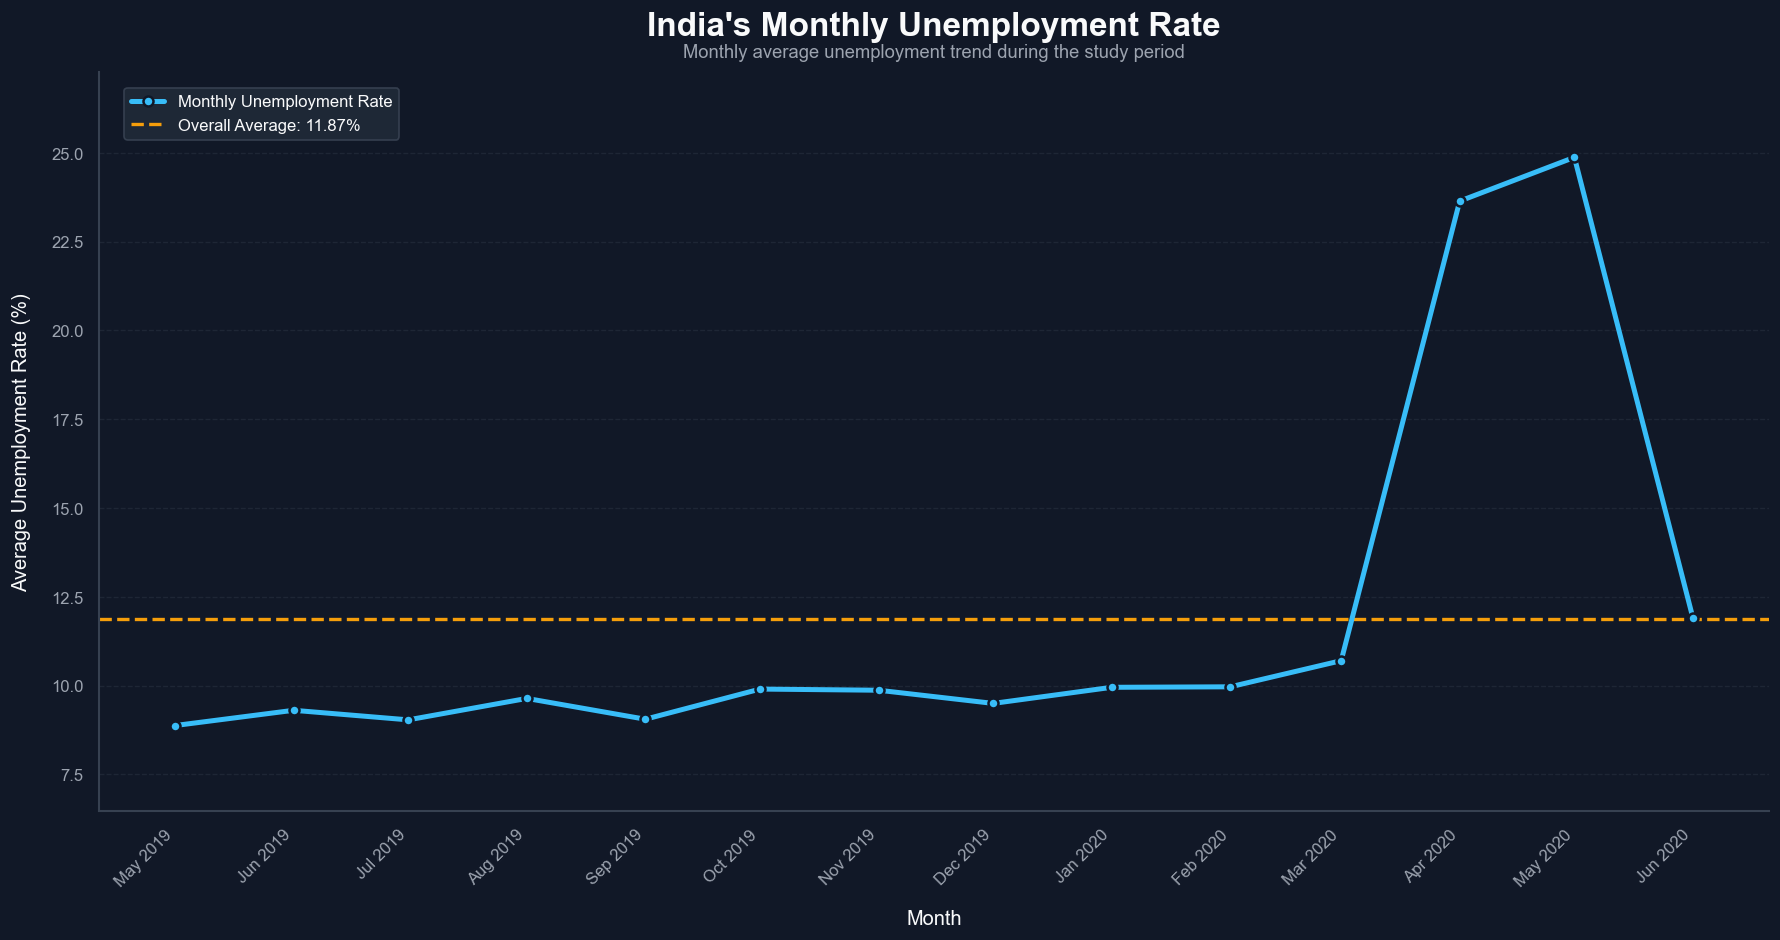

Chart saved successfully: ../images/overall_monthly_unemployment_trend.png


In [2234]:
# ==========================================
# CREATE FIGURE
# ==========================================

fig, ax = plt.subplots(figsize=(15, 8))

# Explicitly set background
fig.patch.set_facecolor(COLORS["background"])
ax.set_facecolor(COLORS["background"])

# ==========================================
# MAIN TREND LINE
# ==========================================

ax.plot(
    monthly_unemployment["Date"],
    monthly_unemployment["Estimated Unemployment Rate (%)"],
    color=COLORS["primary"],
    linewidth=3,
    marker="o",
    markersize=6,
    markerfacecolor=COLORS["primary"],
    markeredgecolor=COLORS["background"],
    markeredgewidth=1.5,
    label="Monthly Unemployment Rate",
    zorder=3
)

# ==========================================
# AVERAGE LINE
# ==========================================

ax.axhline(
    y=average_unemployment,
    color=COLORS["warning"],
    linewidth=2,
    linestyle="--",
    label=f"Overall Average: {average_unemployment:.2f}%",
    zorder=2
)

# ==========================================
# TITLE
# ==========================================

ax.set_title(
    "India's Monthly Unemployment Rate",
    fontsize=20,
    fontweight="bold",
    color=COLORS["text"],
    pad=22
)

# ==========================================
# SUBTITLE
# ==========================================

ax.text(
    0.5,
    1.015,
    "Monthly average unemployment trend during the study period",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=11,
    color=COLORS["muted"]
)

# ==========================================
# AXIS LABELS
# ==========================================

ax.set_xlabel(
    "Month",
    fontsize=12,
    color=COLORS["text"],
    labelpad=12
)

ax.set_ylabel(
    "Average Unemployment Rate (%)",
    fontsize=12,
    color=COLORS["text"],
    labelpad=12
)

# ==========================================
# X-AXIS DATE FORMATTING
# ==========================================

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=1)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right",
    color=COLORS["muted"],
    fontsize=10
)

# ==========================================
# Y-AXIS FORMATTING
# ==========================================

plt.setp(
    ax.get_yticklabels(),
    color=COLORS["muted"],
    fontsize=10
)

# ==========================================
# GRID
# ==========================================

ax.grid(
    axis="y",
    color=COLORS["grid"],
    linestyle="--",
    linewidth=0.8,
    alpha=0.35
)

ax.grid(
    axis="x",
    visible=False
)

# ==========================================
# AXIS SPINES
# ==========================================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(COLORS["grid"])
ax.spines["bottom"].set_color(COLORS["grid"])

# ==========================================
# LEGEND
# ==========================================

legend = ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    fontsize=10
)

# Legend background
legend.get_frame().set_facecolor("#1F2937")
legend.get_frame().set_edgecolor(COLORS["grid"])

# Legend text
for text in legend.get_texts():
    text.set_color(COLORS["text"])

# ==========================================
# Y-AXIS LIMIT
# ==========================================

y_values = monthly_unemployment[
    "Estimated Unemployment Rate (%)"
]

y_min = y_values.min()
y_max = y_values.max()

padding = (y_max - y_min) * 0.15

ax.set_ylim(
    max(0, y_min - padding),
    y_max + padding
)

# ==========================================
# LAYOUT
# ==========================================

plt.tight_layout()

# ==========================================
# SAVE IMAGE
# ==========================================

output_path = "../images/overall_monthly_unemployment_trend.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=COLORS["background"]
)

plt.show()

print(f"Chart saved successfully: {output_path}")

### 🔍 Key Observation

The monthly unemployment trend shows noticeable fluctuations throughout the study period, indicating that unemployment conditions changed significantly over time.

The overall average unemployment rate was **11.87%**, while the highest monthly unemployment rate reached **24.88%** in **May 2020**. The lowest value was **8.87%** in **May 2019**.

The increase around the COVID-19 period indicates a major disruption in employment conditions. However, the subsequent movement of the trend provides an indication of how unemployment conditions changed during the recovery period.

The dashed reference line represents the overall average unemployment rate, making it easier to identify months with unemployment above or below the long-term average.

# 11. Region-wise Average Unemployment Rate

This analysis compares the average unemployment rate across all regions in the dataset. 
Regions are ranked from the highest to the lowest average unemployment rate to identify areas with relatively higher unemployment during the study period.

In [2235]:
region_avg = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

display(region_avg.to_frame("Average Unemployment Rate (%)"))

,Average Unemployment Rate (%)
Region,
Tripura,28.35
Haryana,26.28
Jharkhand,20.59
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Jammu & Kashmir,16.19
Chandigarh,15.99
Rajasthan,14.06


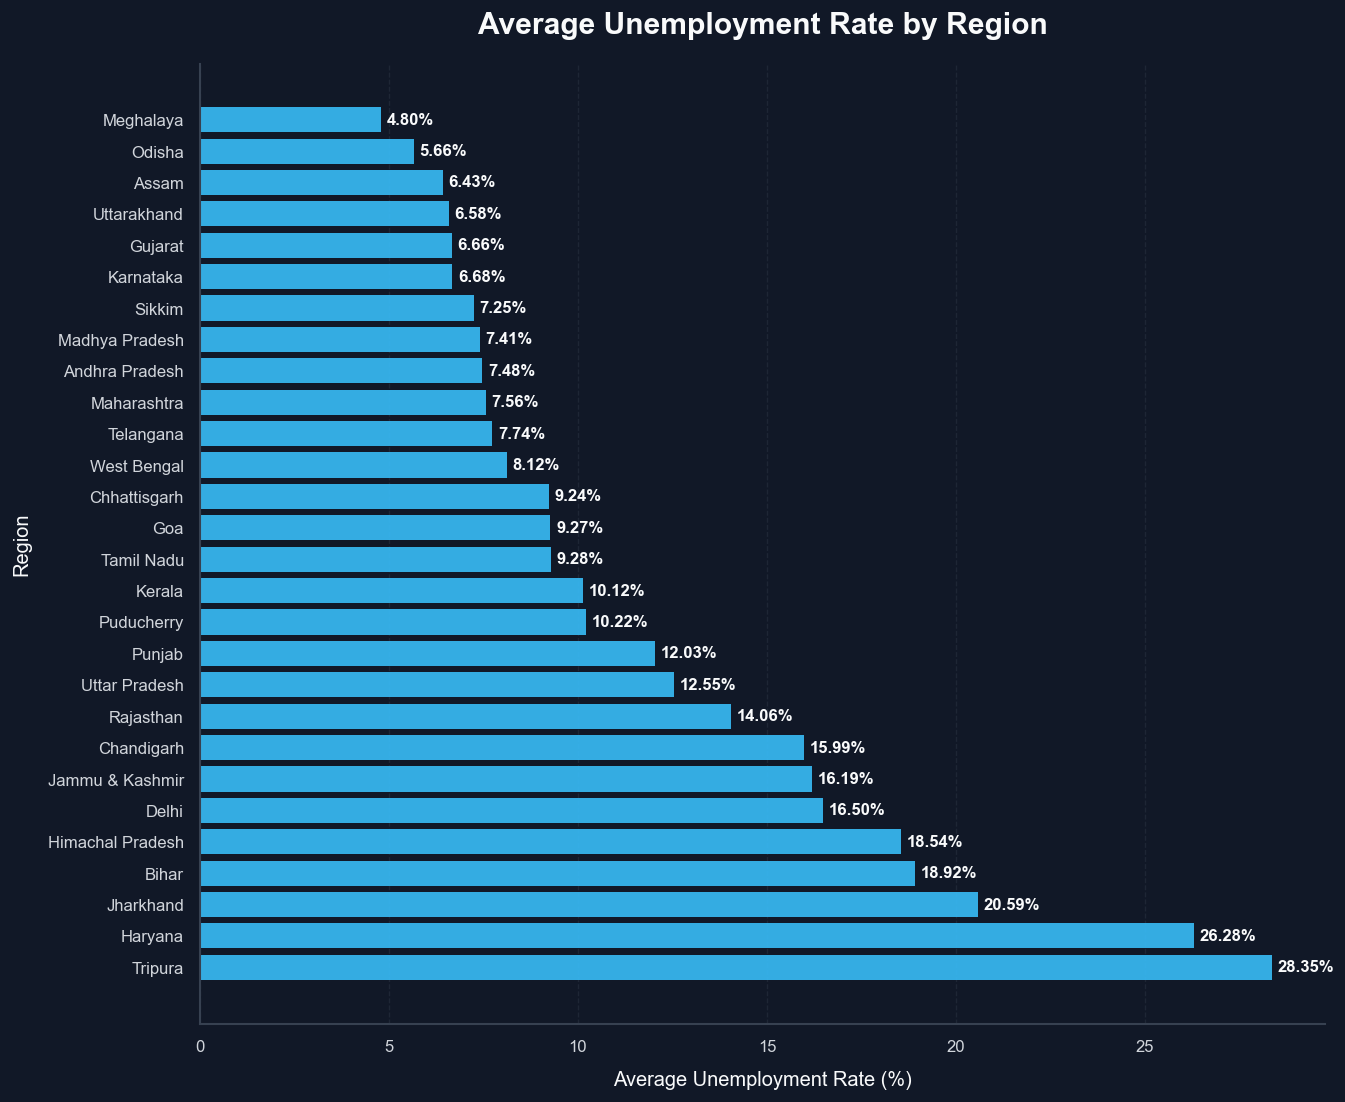

Chart saved successfully: ../images/average_unemployment_by_region.png


In [2236]:
# Create figure
fig, ax = plt.subplots(figsize=(14, 10))

# Create horizontal bar chart
bars = ax.barh(
    region_avg.index,
    region_avg.values,
    color=COLORS["primary"],
    edgecolor="none",
    alpha=0.90
)

# Add value labels to each bar
for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}%",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color=COLORS["text"]
    )

# Chart title
format_chart(
    "Average Unemployment Rate by Region",
    xlabel="Average Unemployment Rate (%)",
    ylabel="Region"
)

# Customize axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Keep grid behind bars
ax.set_axisbelow(True)

# X-axis grid only
ax.grid(
    axis="x",
    color=COLORS["grid"],
    linestyle="--",
    linewidth=0.8,
    alpha=0.35
)

# Remove horizontal grid
ax.grid(axis="y", visible=False)

# Improve tick labels
ax.tick_params(
    axis="y",
    labelsize=10
)

ax.tick_params(
    axis="x",
    labelsize=10
)


# Adjust layout
plt.subplots_adjust(
    left=0.25,
    right=0.92,
    top=0.88,
    bottom=0.08
)

# Save high-resolution image
output_path = "../images/average_unemployment_by_region.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=COLORS["background"]
)

plt.show()

print(f"Chart saved successfully: {output_path}")

In [2237]:
# Identify highest and lowest unemployment regions
highest_region = region_avg.idxmax()
highest_rate = region_avg.max()

lowest_region = region_avg.idxmin()
lowest_rate = region_avg.min()

print(f"Highest average unemployment: {highest_region} ({highest_rate:.2f}%)")
print(f"Lowest average unemployment: {lowest_region} ({lowest_rate:.2f}%)")

Highest average unemployment: Tripura (28.35%)
Lowest average unemployment: Meghalaya (4.80%)


### 🔍 Key Observation

The regional comparison shows noticeable variation in unemployment rates across India.

The region with the highest average unemployment rate recorded a considerably higher unemployment level than the region with the lowest average rate. This indicates that unemployment conditions were not uniform across regions during the study period.

These differences may reflect variations in regional economic activity, employment opportunities, industrial development, labour-market conditions, and seasonal employment patterns.

The ranking provides a useful starting point for identifying regions that may require closer investigation into the underlying causes of higher unemployment.

# 12. Top 10 Regions with Highest Average Unemployment Rate

This visualization ranks the ten regions with the highest average unemployment rates during the observation period.

The chart helps identify which regions consistently experienced relatively higher unemployment, providing insights into regional labour-market disparities.

In [2238]:
top_10_regions = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

display(
    top_10_regions
    .round(2)
    .to_frame("Average Unemployment Rate (%)")
)

,Average Unemployment Rate (%)
Region,
Tripura,28.35
Haryana,26.28
Jharkhand,20.58
Bihar,18.92
Himachal Pradesh,18.54
Delhi,16.50
Jammu & Kashmir,16.19
Chandigarh,15.99
Rajasthan,14.06


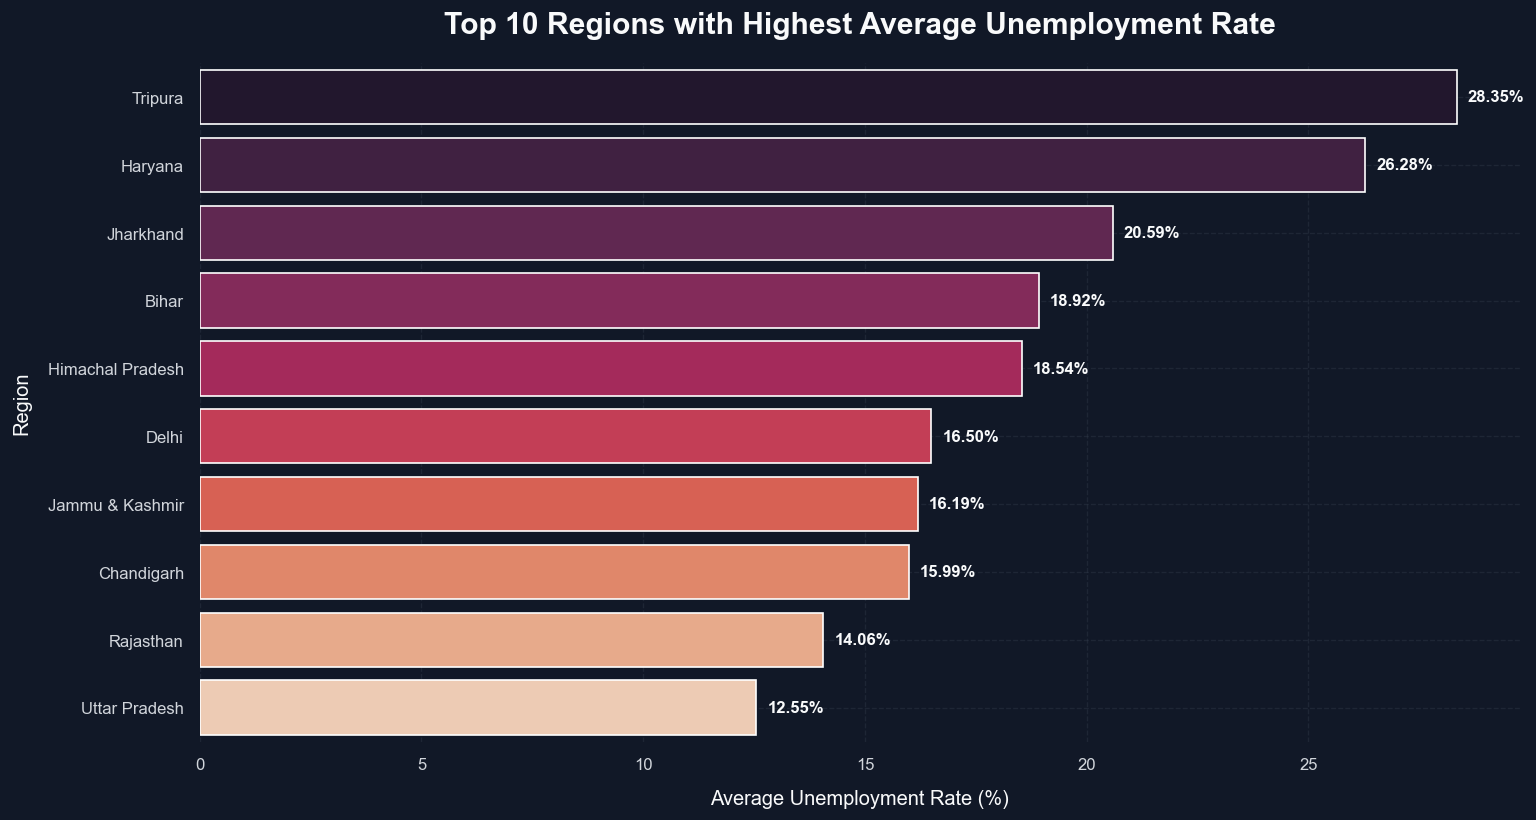

In [2239]:
# Create figure
plt.figure(figsize=(13, 7))

# Horizontal bar chart
ax = sns.barplot(
    x=top_10_regions.values,
    y=top_10_regions.index,
    palette="rocket"
)

# Add percentage labels
for i, value in enumerate(top_10_regions.values):

    ax.text(
        value + 0.25,
        i,
        f"{value:.2f}%",
        va="center",
        fontsize=10,
        color=COLORS["text"],
        fontweight="bold"
    )

# Professional formatting
format_chart(
    title="Top 10 Regions with Highest Average Unemployment Rate",
    xlabel="Average Unemployment Rate (%)",
    ylabel="Region"
)

# Remove unnecessary borders
sns.despine(left=True, bottom=True)

# Save image
plt.savefig(
    "../images/top_10_regions_unemployment.png",
    bbox_inches="tight"
)

plt.show()

### 🔍 Key Observation

- The chart highlights the **top ten regions** with the highest average unemployment rates during the study period.
- The region with the highest average unemployment rate is **Tripura**, while **Uttar Pradesh** ranks tenth among the selected regions.
- The noticeable variation between regions suggests that unemployment conditions are not uniform across India.
- These differences may be influenced by regional economic activity, industrial development, labour demand, seasonal employment, and demographic characteristics.
- Such analysis helps policymakers identify regions that may require targeted employment initiatives and economic support.

# 13. Monthly Unemployment Pattern

This analysis examines the average unemployment rate for each calendar month across the available years in the dataset.

The monthly aggregation helps identify recurring seasonal patterns and months that generally experience relatively higher or lower unemployment rates.

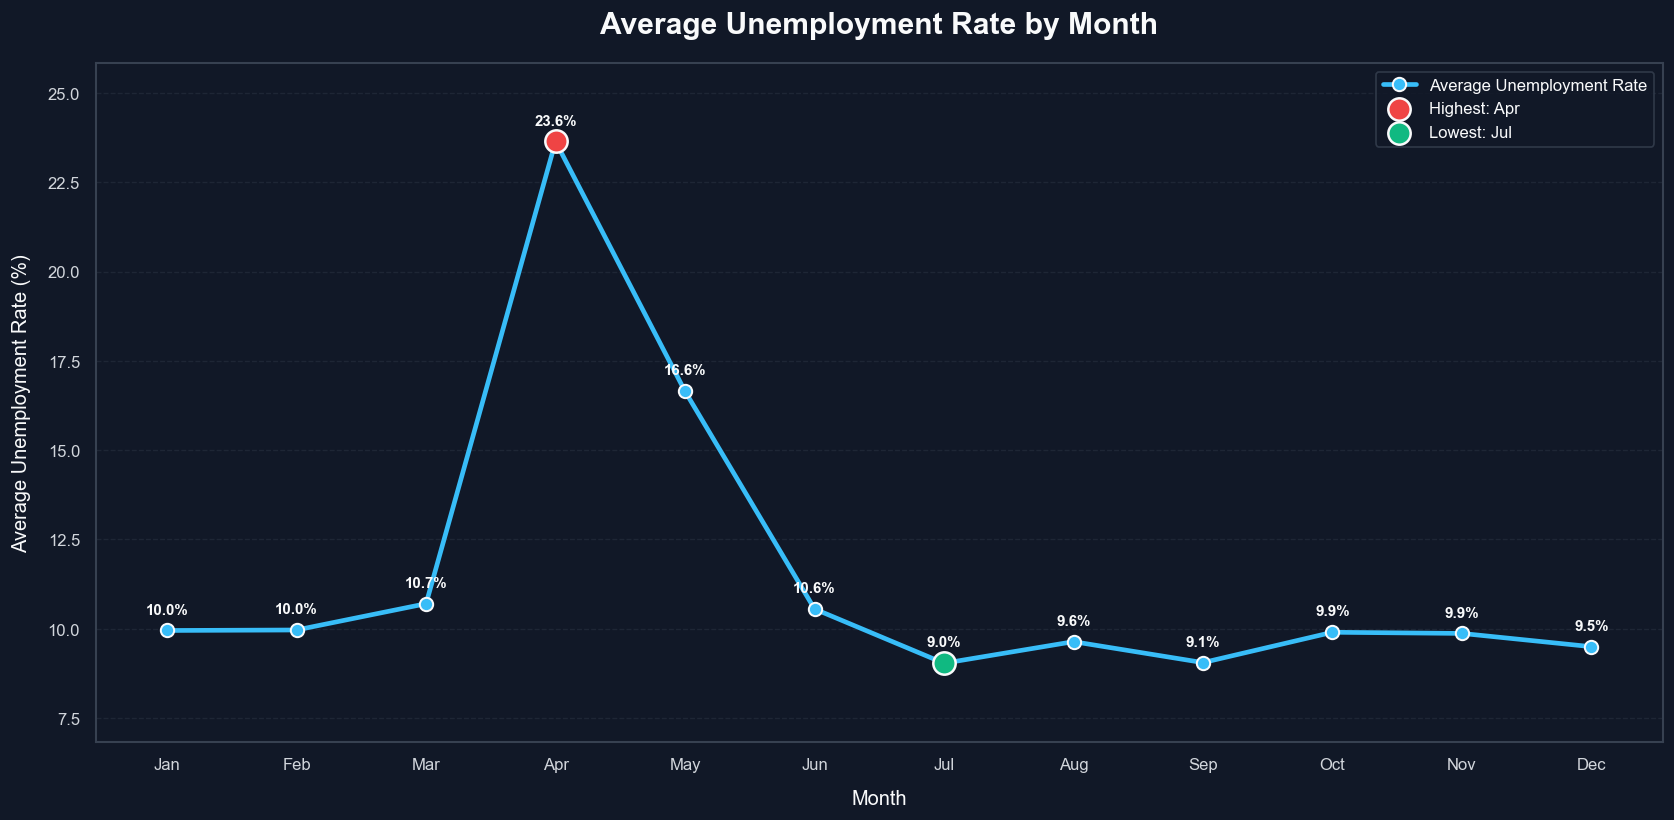

Chart saved successfully: ../images/monthly_unemployment_pattern.png
Highest average unemployment month: Apr (23.64%)
Lowest average unemployment month: Jul (9.03%)


In [2240]:
# ==========================================
# MONTHLY UNEMPLOYMENT PATTERN
# ==========================================

# Calculate average unemployment rate for each month
monthly_pattern = (
    df.groupby("Month")["Estimated Unemployment Rate (%)"]
    .mean()
    .reindex(range(1, 13))
)

# Month labels
month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

# Find highest and lowest unemployment months
highest_month = monthly_pattern.idxmax()
lowest_month = monthly_pattern.idxmin()

highest_value = monthly_pattern.max()
lowest_value = monthly_pattern.min()

# ==========================================
# CREATE FIGURE
# ==========================================

fig, ax = plt.subplots(figsize=(14, 7))

# Main line
ax.plot(
    month_labels,
    monthly_pattern.values,
    marker="o",
    markersize=8,
    linewidth=2.8,
    color=COLORS["primary"],
    markerfacecolor=COLORS["primary"],
    markeredgecolor=COLORS["text"],
    markeredgewidth=1.2,
    label="Average Unemployment Rate"
)

# ==========================================
# HIGHLIGHT HIGHEST MONTH
# ==========================================

ax.scatter(
    highest_month - 1,
    highest_value,
    s=180,
    color=COLORS["danger"],
    edgecolor=COLORS["text"],
    linewidth=1.5,
    zorder=5,
    label=f"Highest: {month_labels[highest_month - 1]}"
)

# ==========================================
# HIGHLIGHT LOWEST MONTH
# ==========================================

ax.scatter(
    lowest_month - 1,
    lowest_value,
    s=180,
    color=COLORS["success"],
    edgecolor=COLORS["text"],
    linewidth=1.5,
    zorder=5,
    label=f"Lowest: {month_labels[lowest_month - 1]}"
)

# ==========================================
# DATA LABELS
# ==========================================

for i, value in enumerate(monthly_pattern.values):

    if pd.notna(value):

        ax.annotate(
            f"{value:.1f}%",
            (i, value),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            fontweight="bold",
            color=COLORS["text"]
        )

# ==========================================
# FORMATTING
# ==========================================

format_chart(
    "Average Unemployment Rate by Month",
    xlabel="Month",
    ylabel="Average Unemployment Rate (%)"
)

# Force all 12 months to appear
ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)

# Improve Y-axis range
y_min = monthly_pattern.min()
y_max = monthly_pattern.max()

padding = (y_max - y_min) * 0.15

if padding == 0:
    padding = 1

ax.set_ylim(
    max(0, y_min - padding),
    y_max + padding
)

# Keep only horizontal gridlines
ax.grid(
    axis="x",
    visible=False
)

# Legend
ax.legend(
    loc="upper right",
    frameon=True,
    facecolor=COLORS["background"],
    edgecolor=COLORS["grid"]
)

# ==========================================
# SAVE CHART
# ==========================================

output_path = "../images/monthly_unemployment_pattern.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=COLORS["background"]
)

plt.show()

print(f"Chart saved successfully: {output_path}")
print(
    f"Highest average unemployment month: "
    f"{month_labels[highest_month - 1]} ({highest_value:.2f}%)"
)
print(
    f"Lowest average unemployment month: "
    f"{month_labels[lowest_month - 1]} ({lowest_value:.2f}%)"
)

### 🔍 Key Observation

The monthly analysis shows that unemployment rates vary across different months, indicating the presence of temporal and potentially seasonal patterns.

The month with the highest average unemployment rate is **Apr**, at approximately **23.64%**, while **Jul** records the lowest average rate of approximately **9.03%**.

These variations suggest that unemployment conditions are not constant throughout the year and may be influenced by seasonal employment patterns, economic activity, and other labour-market factors.

# 14. Urban vs Rural Unemployment Analysis

The dataset contains an `Area` variable that allows comparison of average unemployment rates across different area categories.

A donut chart is used to visualize the relative contribution of each area's average unemployment rate to the combined average across the available area categories.

In [2241]:
# ==========================================
# URBAN VS RURAL UNEMPLOYMENT ANALYSIS
# ==========================================

# Calculate average unemployment rate by area
area_avg = (
    df.groupby("Area")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

# Display summary table
area_summary = area_avg.to_frame(
    "Average Unemployment Rate (%)"
)

display(
    area_summary.style.format(
        "{:.2f}%"
    )
)

,Average Unemployment Rate (%)
Area,
Urban,13.17%
Rural,10.32%


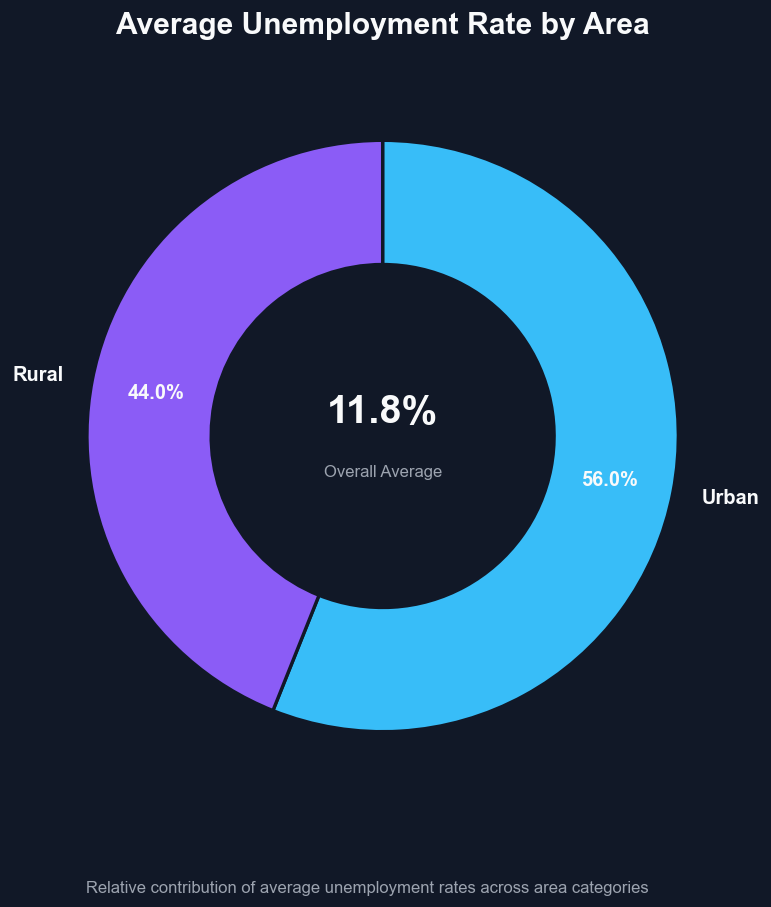

Chart saved successfully: ../images/area_unemployment_donut.png


In [2242]:
# ------------------------------------------
# Calculate percentage contribution
# ------------------------------------------

area_percentage = (
    area_avg / area_avg.sum()
) * 100

# ------------------------------------------
# Create professional donut chart
# ------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 8),
    facecolor=COLORS["background"]
)

# Use consistent professional colors
chart_colors = [
    COLORS["primary"],
    COLORS["secondary"],
    COLORS["success"],
    COLORS["warning"]
]

# Keep only the colors required
chart_colors = chart_colors[:len(area_avg)]

wedges, texts, autotexts = ax.pie(
    area_avg.values,
    labels=area_avg.index,
    autopct=lambda pct: f"{pct:.1f}%",
    startangle=90,
    counterclock=False,
    colors=chart_colors,
    pctdistance=0.78,
    wedgeprops={
        "width": 0.42,
        "edgecolor": COLORS["background"],
        "linewidth": 2
    },
    textprops={
        "color": COLORS["text"],
        "fontsize": 12,
        "fontweight": "bold"
    }
)

# ------------------------------------------
# Format percentage labels
# ------------------------------------------

for autotext in autotexts:
    autotext.set_color(COLORS["text"])
    autotext.set_fontsize(12)
    autotext.set_fontweight("bold")

# ------------------------------------------
# Center KPI
# ------------------------------------------

overall_average = df[
    "Estimated Unemployment Rate (%)"
].mean()

ax.text(
    0,
    0.08,
    f"{overall_average:.1f}%",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold",
    color=COLORS["text"]
)

ax.text(
    0,
    -0.12,
    "Overall Average",
    ha="center",
    va="center",
    fontsize=10,
    color=COLORS["muted"]
)

# ------------------------------------------
# Title
# ------------------------------------------

ax.set_title(
    "Average Unemployment Rate by Area",
    fontsize=18,
    fontweight="bold",
    color=COLORS["text"],
    pad=20
)

# ------------------------------------------
# Subtitle
# ------------------------------------------

fig.text(
    0.5,
    0.02,
    "Relative contribution of average unemployment rates across area categories",
    ha="center",
    fontsize=10,
    color=COLORS["muted"]
)

# ------------------------------------------
# Save chart
# ------------------------------------------

output_path = "../images/area_unemployment_donut.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=COLORS["background"]
)

plt.show()

print(f"Chart saved successfully: {output_path}")

### 🔍 Key Observation

The analysis shows a clear difference in average unemployment rates across the available area categories.

The area with the largest share in the donut chart contributes the highest average unemployment rate, while the area with the smallest share contributes the lowest.

This indicates that unemployment conditions vary between area categories and highlights the importance of considering geographic and demographic differences when analyzing India's labour market.

> **Note:** The percentages shown in the donut chart represent each area's contribution to the combined average unemployment-rate values. They do not represent the percentage of unemployed people in each area.

# 15. Distribution of Unemployment Rate

A box plot is used to understand the distribution of unemployment rates across the dataset.

The chart highlights:

- Median unemployment rate
- Interquartile range (IQR)
- Overall variability
- Potential outliers

This helps identify whether unusually high or low unemployment observations exist in the dataset.

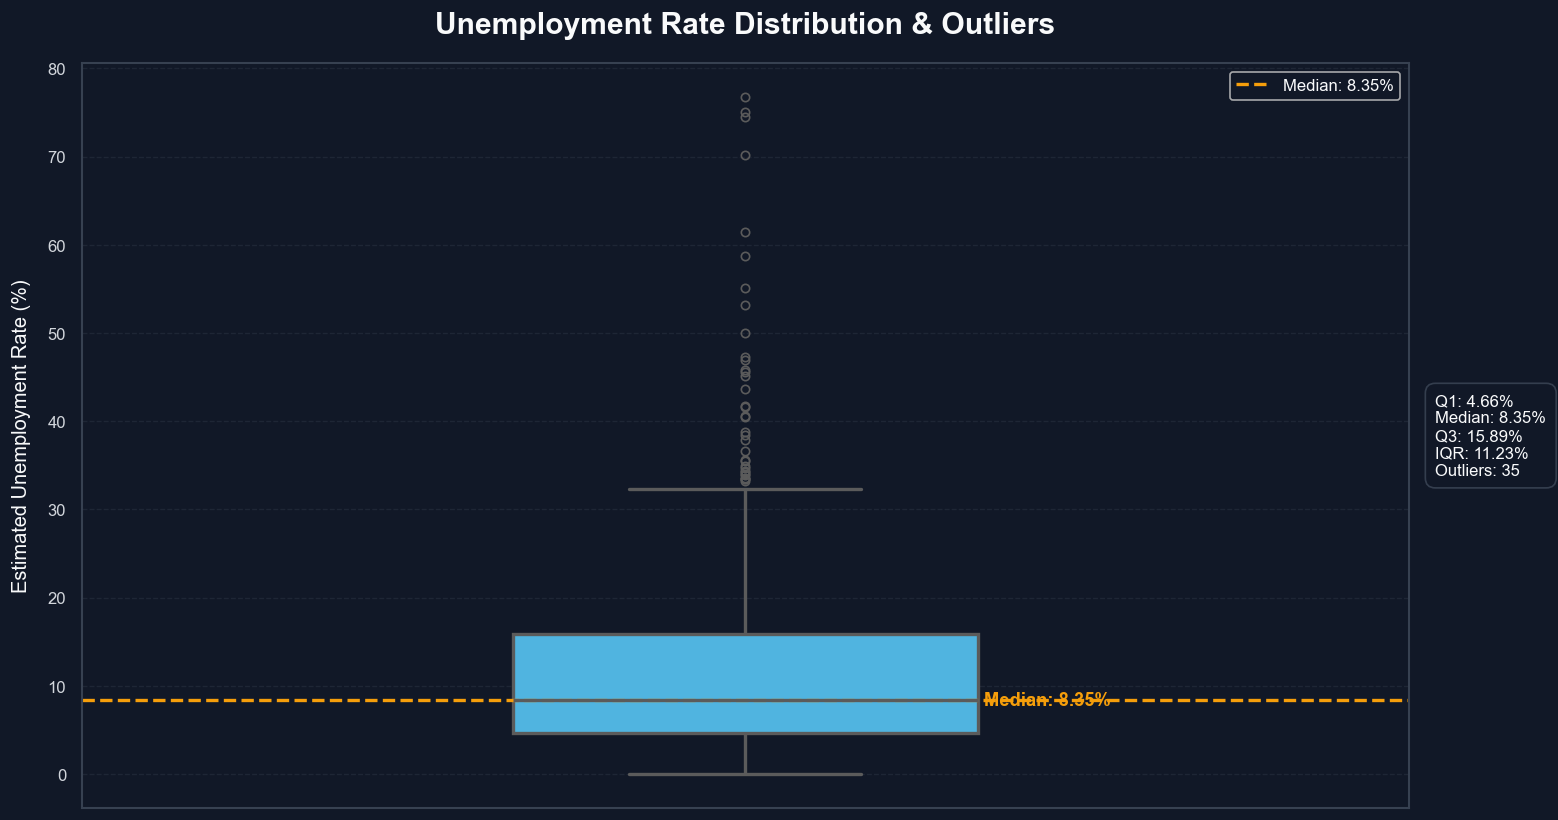

Chart saved successfully: ../images/unemployment_rate_distribution_boxplot.png


In [2243]:
# ==========================================
# CHART: UNEMPLOYMENT RATE DISTRIBUTION
# ==========================================

# Calculate key statistics
unemployment = df["Estimated Unemployment Rate (%)"].dropna()

median_rate = unemployment.median()
q1_rate = unemployment.quantile(0.25)
q3_rate = unemployment.quantile(0.75)
iqr_rate = q3_rate - q1_rate

# Calculate outlier boundaries
lower_bound = q1_rate - 1.5 * iqr_rate
upper_bound = q3_rate + 1.5 * iqr_rate

outlier_count = (
    (unemployment < lower_bound) |
    (unemployment > upper_bound)
).sum()

# ------------------------------------------
# Create figure
# ------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

# Boxplot
sns.boxplot(
    y=unemployment,
    width=0.35,
    color=COLORS["primary"],
    linewidth=2,
    fliersize=5,
    ax=ax
)

# ------------------------------------------
# Median reference line
# ------------------------------------------

ax.axhline(
    median_rate,
    color=COLORS["warning"],
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_rate:.2f}%"
)

# ------------------------------------------
# Median annotation
# ------------------------------------------

ax.annotate(
    f"Median: {median_rate:.2f}%",
    xy=(0, median_rate),
    xytext=(0.18, median_rate),
    textcoords="data",
    color=COLORS["warning"],
    fontsize=11,
    fontweight="bold",
    va="center"
)

# ------------------------------------------
# Chart formatting
# ------------------------------------------

format_chart(
    "Unemployment Rate Distribution & Outliers",
    ylabel="Estimated Unemployment Rate (%)"
)

ax.set_xticks([])

ax.legend(
    loc="upper right",
    frameon=True
)

# ------------------------------------------
# Add statistical summary
# ------------------------------------------

stats_text = (
    f"Q1: {q1_rate:.2f}%\n"
    f"Median: {median_rate:.2f}%\n"
    f"Q3: {q3_rate:.2f}%\n"
    f"IQR: {iqr_rate:.2f}%\n"
    f"Outliers: {outlier_count}"
)

ax.text(
    1.02,
    0.50,
    stats_text,
    transform=ax.transAxes,
    fontsize=10,
    color=COLORS["text"],
    verticalalignment="center",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor=COLORS["background"],
        edgecolor=COLORS["grid"],
        alpha=0.95
    )
)

# ------------------------------------------
# Save chart
# ------------------------------------------

output_path = "../images/unemployment_rate_distribution_boxplot.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=COLORS["background"]
)

plt.show()

print(f"Chart saved successfully: {output_path}")

### 🔍 Key Observation

The box plot shows the overall distribution and variability of unemployment rates in the dataset.

The median represents the typical unemployment rate, while the interquartile range (IQR) represents the middle 50% of observations. Points outside the whiskers are potential statistical outliers and may represent periods or regions with unusually high or low unemployment.

The distribution indicates that unemployment rates are not completely uniform across the observations, highlighting variation in labour-market conditions across different regions and time periods.

# 16. Unemployment Trends for Three Major Regions

To compare regional unemployment patterns over time, the three regions with the highest number of observations are selected. A time-series line chart is used to examine how their unemployment rates changed throughout the study period.

The comparison helps identify whether unemployment movements were similar or different across regions, particularly around the COVID-19 period.

In [2244]:
region_counts = df["Region"].value_counts()

selected_regions = region_counts.head(3).index.tolist()

print("Selected regions:")
for i, region in enumerate(selected_regions, start=1):
    print(f"{i}. {region}")

Selected regions:
1. Andhra Pradesh
2. Kerala
3. West Bengal


In [2245]:
selected_df = (
    df[df["Region"].isin(selected_regions)]
    .copy()
    .sort_values("Date")
)

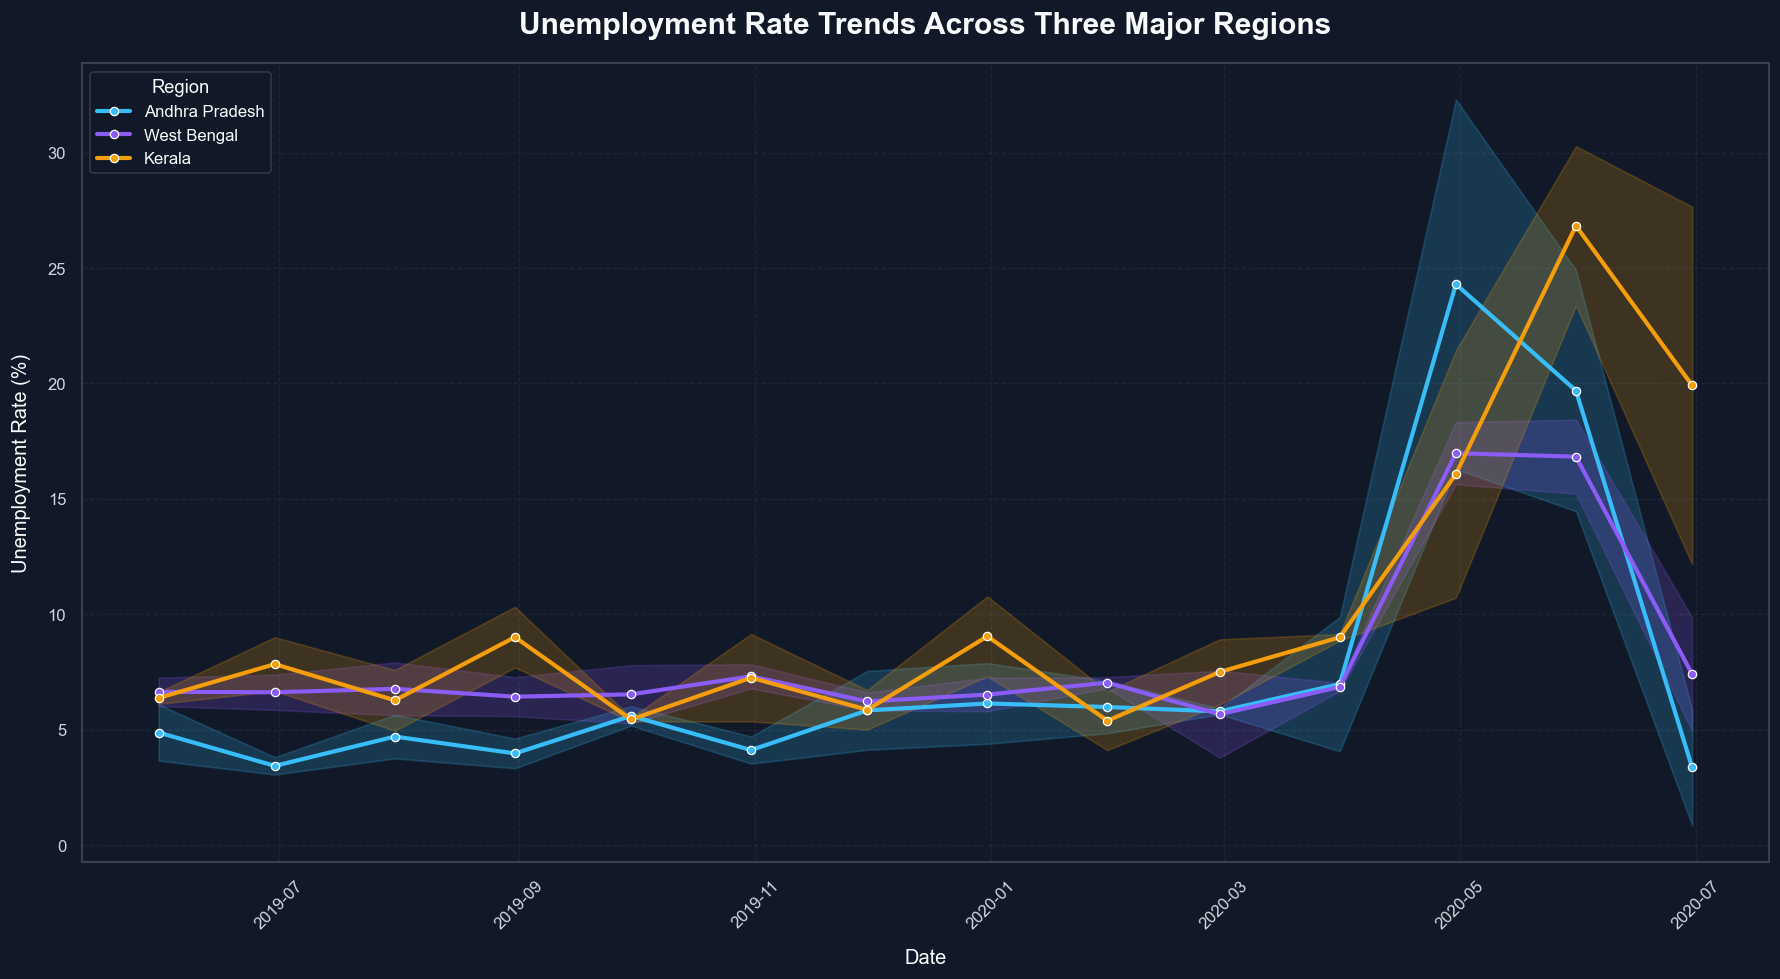


Chart saved successfully:
../images/three_region_unemployment_trends.png


In [2246]:
# ==========================================
# CREATE CHART
# ==========================================

plt.figure(figsize=(15, 8))

sns.lineplot(
    data=selected_df,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o",
    linewidth=2.5,
    markersize=5,
    palette=[
        COLORS["primary"],
        COLORS["secondary"],
        COLORS["warning"]
    ]
)

# ==========================================
# CHART FORMATTING
# ==========================================

format_chart(
    "Unemployment Rate Trends Across Three Major Regions",
    xlabel="Date",
    ylabel="Unemployment Rate (%)"
)

# Rotate date labels
plt.xticks(rotation=45)

# Improve legend
legend = plt.legend(
    title="Region",
    title_fontsize=11,
    fontsize=10,
    loc="upper left",
    frameon=True
)

legend.get_frame().set_facecolor(COLORS["background"])
legend.get_frame().set_edgecolor(COLORS["grid"])

# ==========================================
# SAVE CHART
# ==========================================

chart_path = "../images/three_region_unemployment_trends.png"

plt.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nChart saved successfully:")
print(chart_path)

### 🔍 Key Observation

The time-series comparison shows that unemployment rates varied across the three selected regions throughout the study period.

The three regions do not follow exactly the same pattern, indicating differences in regional labour-market conditions. A noticeable change in unemployment can also be observed around the COVID-19 period, when economic activity was significantly disrupted.

The comparison demonstrates that unemployment trends in India were not uniform across regions and that regional conditions played an important role in determining unemployment levels.

# 17. Correlation Analysis

Correlation analysis is used to examine the relationship between unemployment, employment, and labour force participation.

The correlation coefficient ranges from **-1 to +1**:

- **+1** indicates a strong positive relationship.
- **0** indicates little or no linear relationship.
- **-1** indicates a strong negative relationship.

This analysis helps identify how the major employment indicators move in relation to one another.

In [2247]:
# ==========================================
# CORRELATION HEATMAP
# ==========================================

correlation_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

# Calculate correlation matrix
correlation_matrix = df[correlation_columns].corr()

# Display correlation values
display(
    correlation_matrix.style
    .format("{:.2f}")
    .set_caption("Correlation Matrix of Employment Indicators")
)

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.00,-0.22,0.00
Estimated Employed,-0.22,1.00,0.01
Estimated Labour Participation Rate (%),0.00,0.01,1.00


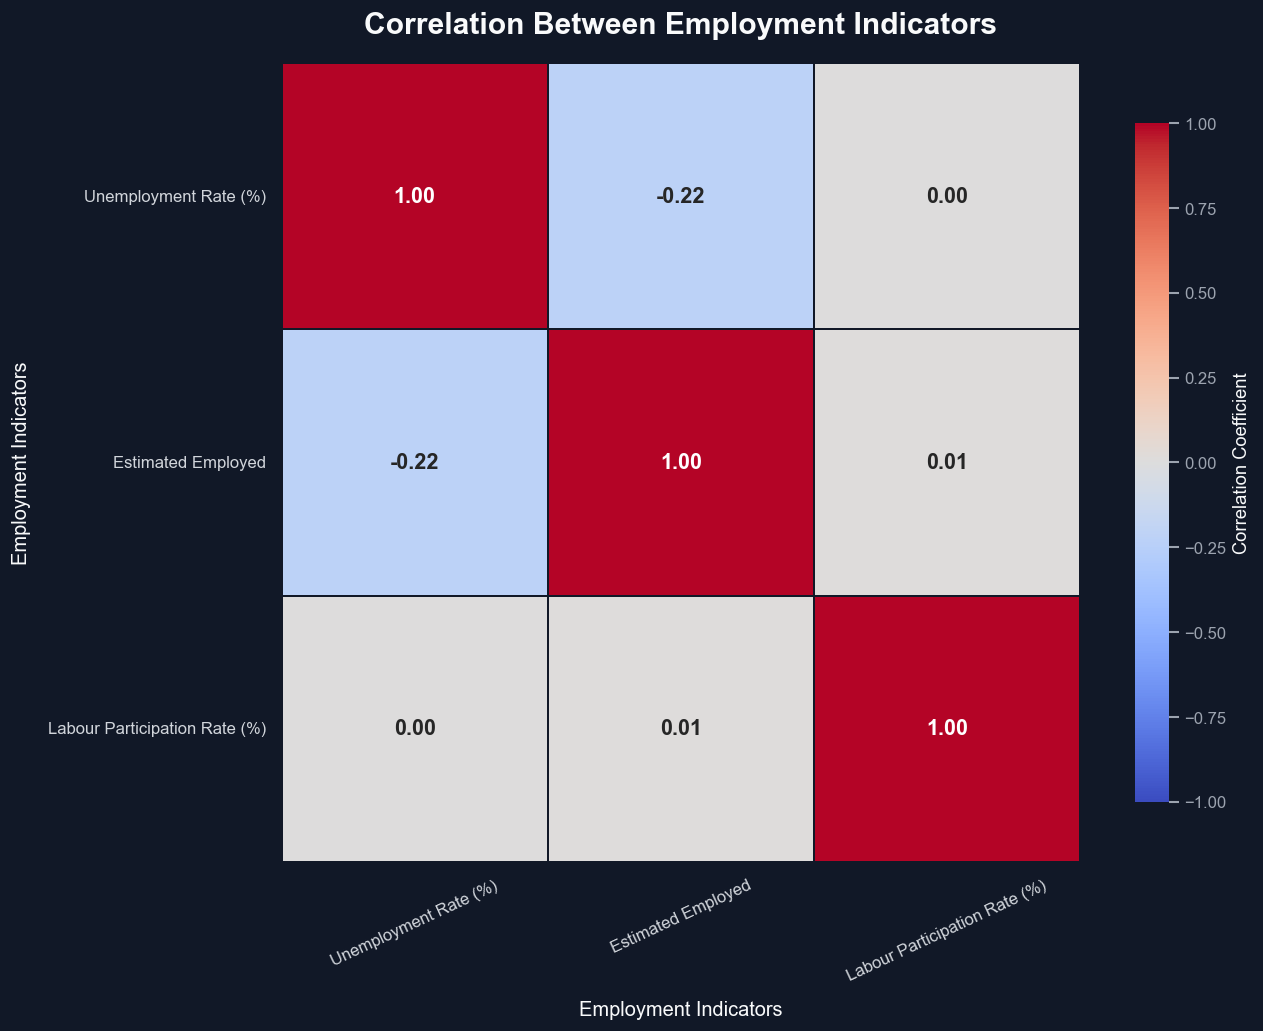

Chart saved successfully: ../images/correlation_employment_indicators.png


In [2248]:
# ------------------------------------------
# Create readable labels for visualization
# ------------------------------------------

correlation_labels = {
    "Estimated Unemployment Rate (%)": "Unemployment Rate (%)",
    "Estimated Employed": "Estimated Employed",
    "Estimated Labour Participation Rate (%)": "Labour Participation Rate (%)"
}

correlation_plot = correlation_matrix.rename(
    index=correlation_labels,
    columns=correlation_labels
)

# ------------------------------------------
# Create figure
# ------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

fig.patch.set_facecolor(COLORS["background"])
ax.set_facecolor(COLORS["background"])

# ------------------------------------------
# Heatmap
# ------------------------------------------

sns.heatmap(
    correlation_plot,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1.2,
    linecolor=COLORS["background"],
    cbar_kws={
        "label": "Correlation Coefficient",
        "shrink": 0.85
    },
    annot_kws={
        "fontsize": 13,
        "fontweight": "bold"
    },
    ax=ax
)

# ------------------------------------------
# Title and labels
# ------------------------------------------

format_chart(
    "Correlation Between Employment Indicators",
    xlabel="Employment Indicators",
    ylabel="Employment Indicators"
)

# ------------------------------------------
# Tick formatting
# ------------------------------------------

ax.tick_params(
    axis="x",
    rotation=25,
    labelsize=10
)

ax.tick_params(
    axis="y",
    rotation=0,
    labelsize=10
)

# ------------------------------------------
# Colorbar formatting
# ------------------------------------------

cbar = ax.collections[0].colorbar

cbar.ax.tick_params(
    colors=COLORS["muted"]
)

cbar.set_label(
    "Correlation Coefficient",
    color=COLORS["text"],
    fontsize=11
)

# ------------------------------------------
# Save high-resolution image
# ------------------------------------------

output_path = "../images/correlation_employment_indicators.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=COLORS["background"
    ],
    edgecolor=COLORS["background"]
)

plt.show()

print(f"Chart saved successfully: {output_path}")

### 🔍 Key Observation

The heatmap shows the strength and direction of the relationships between unemployment, employment, and labour participation.

The diagonal values are **1.00** because each variable has a perfect correlation with itself.

The off-diagonal values are more important for interpretation. In particular, the relationship between the **Unemployment Rate and Labour Participation Rate**, as well as the relationship between **Unemployment Rate and Estimated Employment**, can provide useful insight into labour-market conditions.

The correlation values should be interpreted as **linear relationships rather than causal relationships**. A correlation between two variables does not necessarily mean that one variable causes changes in the other.

# 18. Pre-COVID vs Post-COVID Analysis

The COVID-19 pandemic caused significant disruption to economic activity and employment.

For this analysis, 25 March 2020 is used as the cutoff date:

- **Pre-COVID:** Before 25 March 2020
- **Post-COVID:** On or after 25 March 2020

The average unemployment rate for both periods is compared to understand the change in unemployment conditions.

In [2249]:
# ==========================================
# COVID-19 PERIOD CLASSIFICATION
# ==========================================

covid_cutoff = pd.Timestamp("2020-03-25")

df["COVID_Period"] = np.where(
    df["Date"] < covid_cutoff,
    "Pre-COVID",
    "Post-COVID"
)

print("COVID Period Distribution:")
display(df["COVID_Period"].value_counts())

COVID Period Distribution:


COVID_Period
Pre-COVID     536
Post-COVID    204
Name: count, dtype: int64

In [2250]:
# ==========================================
# PRE-COVID VS POST-COVID SUMMARY
# ==========================================

covid_comparison = (
    df.groupby("COVID_Period")
    .agg(
        Average_Unemployment_Rate=(
            "Estimated Unemployment Rate (%)",
            "mean"
        ),
        Average_Employment=(
            "Estimated Employed",
            "mean"
        ),
        Average_Labour_Participation=(
            "Estimated Labour Participation Rate (%)",
            "mean"
        )
    )
    .reindex(["Pre-COVID", "Post-COVID"])
)

# Round values for clean presentation
covid_comparison = covid_comparison.round(2)

display(covid_comparison)

,Average_Unemployment_Rate,Average_Employment,Average_Labour_Participation
COVID_Period,,,
Pre-COVID,9.51,"7,466,027.87",43.89
Post-COVID,17.77,"6,517,203.34",39.33


In [2251]:
# ==========================================
# COVID-19 UNEMPLOYMENT CHANGE
# ==========================================

pre_covid_rate = covid_comparison.loc[
    "Pre-COVID",
    "Average_Unemployment_Rate"
]

post_covid_rate = covid_comparison.loc[
    "Post-COVID",
    "Average_Unemployment_Rate"
]

absolute_change = post_covid_rate - pre_covid_rate

percentage_change = (
    absolute_change / pre_covid_rate
) * 100

print(f"Pre-COVID unemployment rate : {pre_covid_rate:.2f}%")
print(f"Post-COVID unemployment rate: {post_covid_rate:.2f}%")
print(f"Absolute change             : {absolute_change:+.2f} percentage points")
print(f"Percentage change           : {percentage_change:+.2f}%")

Pre-COVID unemployment rate : 9.51%
Post-COVID unemployment rate: 17.77%
Absolute change             : +8.26 percentage points
Percentage change           : +86.86%


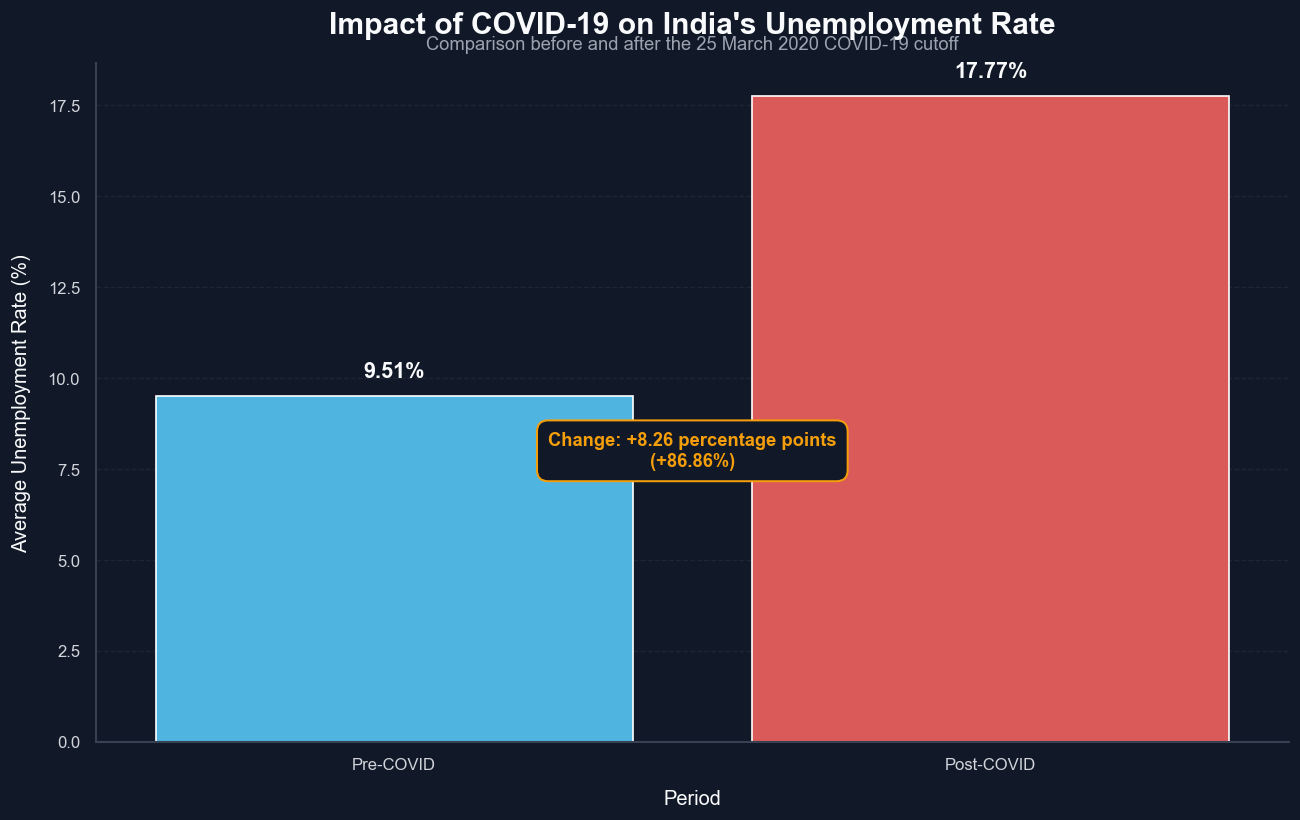

Chart saved successfully: ../images/covid_unemployment_comparison.png


In [2252]:
# ==========================================
# PRE-COVID VS POST-COVID VISUALIZATION
# ==========================================

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    x=covid_rates.index,
    y=covid_rates.values,
    hue=covid_rates.index,
    palette=[
        COLORS["primary"],
        COLORS["danger"]
    ],
    legend=False
)

# ------------------------------------------
# Add value labels
# ------------------------------------------

for i, value in enumerate(covid_rates.values):

    ax.text(
        i,
        value + 0.4,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        color=COLORS["text"]
    )

# ------------------------------------------
# Add change annotation
# ------------------------------------------

middle_x = 0.5
max_rate = max(covid_rates.values)

change_text = (
    f"Change: {absolute_change:+.2f} percentage points\n"
    f"({percentage_change:+.2f}%)"
)

ax.text(
    middle_x,
    max_rate * 0.45,
    change_text,
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    color=COLORS["warning"],
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor=COLORS["background"],
        edgecolor=COLORS["warning"],
        linewidth=1.2
    )
)

# ------------------------------------------
# Chart formatting
# ------------------------------------------

format_chart(
    "Impact of COVID-19 on India's Unemployment Rate",
    "Period",
    "Average Unemployment Rate (%)"
)

# Add explanatory subtitle
plt.text(
    0.5,
    1.02,
    "Comparison before and after the 25 March 2020 COVID-19 cutoff",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color=COLORS["muted"]
)

# Remove unnecessary borders
sns.despine(
    ax=ax,
    left=False,
    bottom=False
)

# ------------------------------------------
# Save chart
# ------------------------------------------

covid_chart_path = (
    "../images/covid_unemployment_comparison.png"
)

plt.savefig(
    covid_chart_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=COLORS["background"]
)

plt.show()

print(
    f"Chart saved successfully: {covid_chart_path}"
)

## 🔍 Key Observation

The comparison between the Pre-COVID and Post-COVID periods shows a clear change in India's average unemployment rate around the COVID-19 period.

The average unemployment rate changed from **9.51%** before the COVID-19 cutoff to **17.77%** after the cutoff, representing a change of **+86.86 % percentage points**.

This indicates that the COVID-19 period was associated with a significant change in labour-market conditions. The result should be interpreted as an association observed in the dataset rather than proof that COVID-19 alone caused the change, since unemployment can also be affected by seasonal, regional, and economic factors.

### 🔍 Key Takeaway

The Pre-COVID vs Post-COVID comparison highlights the importance of examining major economic events when analyzing unemployment trends over time.

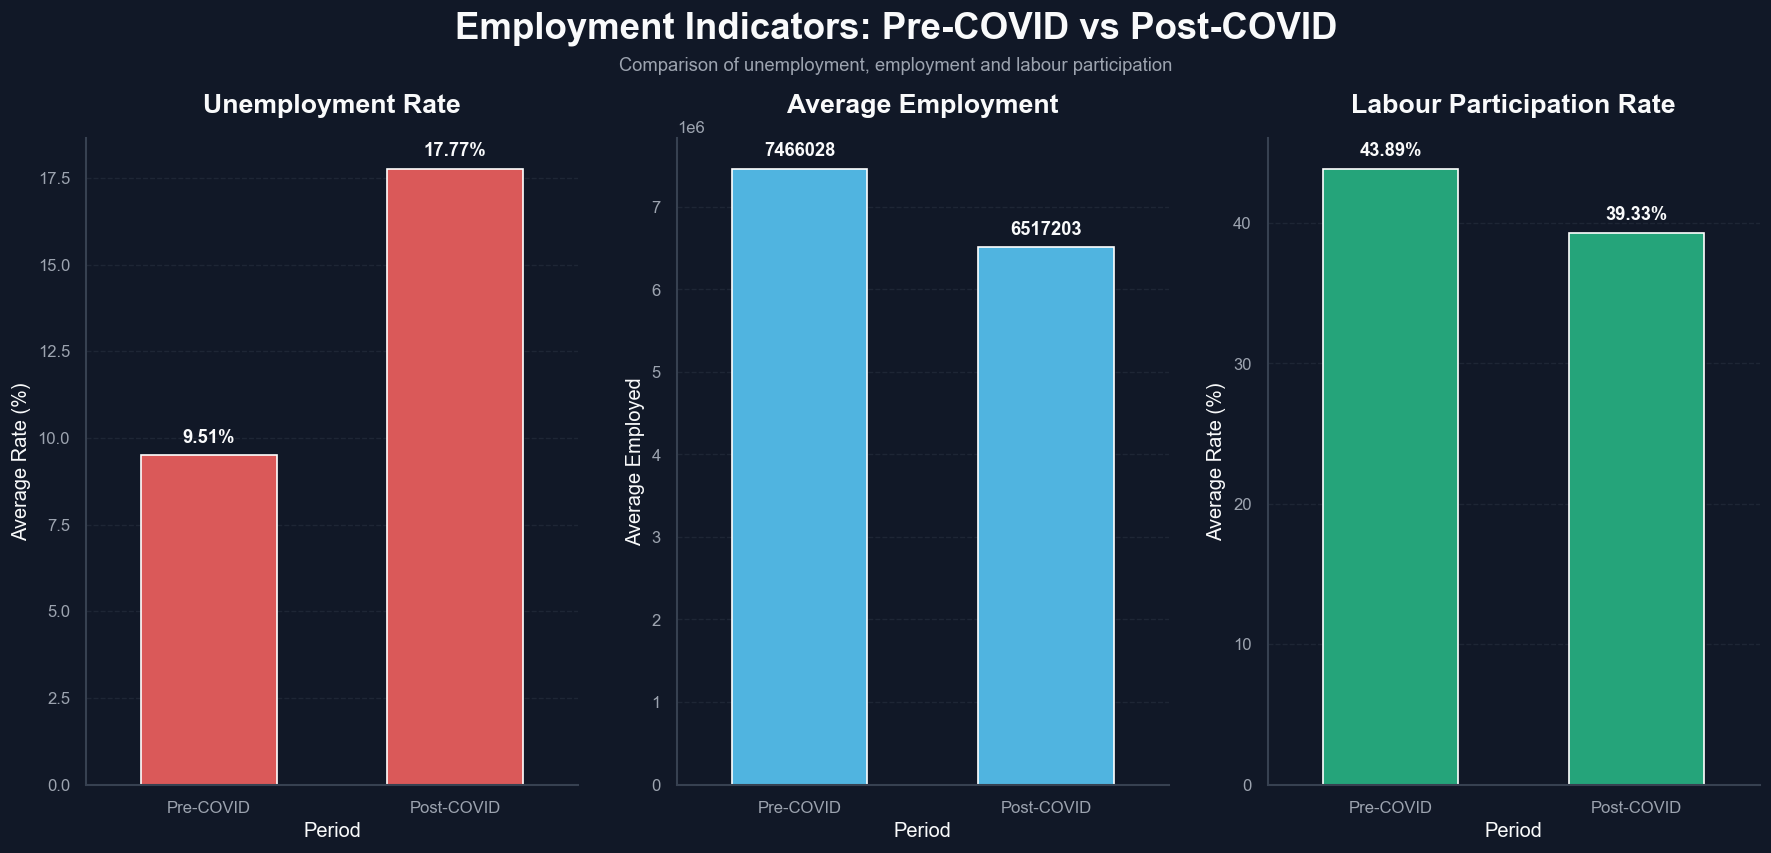

Chart saved successfully: ../images/pre_post_covid_employment_indicators.png


In [2253]:
# ============================================================
# PRE-COVID VS POST-COVID — EMPLOYMENT INDICATORS
# ============================================================

# Ensure the output directory exists
os.makedirs("../images", exist_ok=True)

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

covid_metrics = covid_comparison[
    [
        "Average_Unemployment_Rate",
        "Average_Employment",
        "Average_Labour_Participation"
    ]
].copy()

# Keep the logical order
covid_metrics = covid_metrics.reindex(
    ["Pre-COVID", "Post-COVID"]
)

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 7)
)

fig.patch.set_facecolor(COLORS["background"])

# ------------------------------------------------------------
# Metric 1 — Unemployment Rate
# ------------------------------------------------------------

sns.barplot(
    x=covid_metrics.index,
    y=covid_metrics["Average_Unemployment_Rate"],
    ax=axes[0],
    color=COLORS["danger"],
    width=0.55
)

axes[0].set_title(
    "Unemployment Rate",
    fontsize=16,
    fontweight="bold",
    color=COLORS["text"],
    pad=15
)

axes[0].set_xlabel("Period", color=COLORS["text"])
axes[0].set_ylabel("Average Rate (%)", color=COLORS["text"])

# Add values
for container in axes[0].containers:
    axes[0].bar_label(
        container,
        fmt="%.2f%%",
        color=COLORS["text"],
        fontsize=11,
        fontweight="bold",
        padding=5
    )

# ------------------------------------------------------------
# Metric 2 — Employment
# ------------------------------------------------------------

sns.barplot(
    x=covid_metrics.index,
    y=covid_metrics["Average_Employment"],
    ax=axes[1],
    color=COLORS["primary"],
    width=0.55
)

axes[1].set_title(
    "Average Employment",
    fontsize=16,
    fontweight="bold",
    color=COLORS["text"],
    pad=15
)

axes[1].set_xlabel("Period", color=COLORS["text"])
axes[1].set_ylabel("Average Employed", color=COLORS["text"])

# Add values
for container in axes[1].containers:
    axes[1].bar_label(
        container,
        fmt="%.0f",
        color=COLORS["text"],
        fontsize=11,
        fontweight="bold",
        padding=5
    )

# ------------------------------------------------------------
# Metric 3 — Labour Participation
# ------------------------------------------------------------

sns.barplot(
    x=covid_metrics.index,
    y=covid_metrics["Average_Labour_Participation"],
    ax=axes[2],
    color=COLORS["success"],
    width=0.55
)

axes[2].set_title(
    "Labour Participation Rate",
    fontsize=16,
    fontweight="bold",
    color=COLORS["text"],
    pad=15
)

axes[2].set_xlabel("Period", color=COLORS["text"])
axes[2].set_ylabel("Average Rate (%)", color=COLORS["text"])

# Add values
for container in axes[2].containers:
    axes[2].bar_label(
        container,
        fmt="%.2f%%",
        color=COLORS["text"],
        fontsize=11,
        fontweight="bold",
        padding=5
    )

# ------------------------------------------------------------
# Common formatting
# ------------------------------------------------------------

for ax in axes:

    ax.set_facecolor(COLORS["background"])

    ax.tick_params(
        axis="x",
        colors=COLORS["muted"],
        labelsize=10
    )

    ax.tick_params(
        axis="y",
        colors=COLORS["muted"],
        labelsize=10
    )

    ax.grid(
        axis="y",
        color=COLORS["grid"],
        linestyle="--",
        linewidth=0.8,
        alpha=0.35
    )

    # Remove unnecessary borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color(COLORS["grid"])
    ax.spines["bottom"].set_color(COLORS["grid"])

# ------------------------------------------------------------
# Main title
# ------------------------------------------------------------

fig.suptitle(
    "Employment Indicators: Pre-COVID vs Post-COVID",
    fontsize=22,
    fontweight="bold",
    color=COLORS["text"],
    y=1.03
)

fig.text(
    0.5,
    0.96,
    "Comparison of unemployment, employment and labour participation",
    ha="center",
    fontsize=11,
    color=COLORS["muted"]
)

# ------------------------------------------------------------
# Save high-resolution image
# ------------------------------------------------------------

output_path = "../images/pre_post_covid_employment_indicators.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

print(f"Chart saved successfully: {output_path}")

In [2254]:
# ============================================================
# COVID PERIOD CHANGE SUMMARY
# ============================================================

pre = covid_metrics.loc["Pre-COVID"]
post = covid_metrics.loc["Post-COVID"]

unemployment_change = (
    post["Average_Unemployment_Rate"]
    - pre["Average_Unemployment_Rate"]
)

employment_change = (
    post["Average_Employment"]
    - pre["Average_Employment"]
)

labour_change = (
    post["Average_Labour_Participation"]
    - pre["Average_Labour_Participation"]
)

print(
    f"Unemployment rate change: "
    f"{unemployment_change:+.2f} percentage points"
)

print(
    f"Average employment change: "
    f"{employment_change:+,.0f}"
)

print(
    f"Labour participation change: "
    f"{labour_change:+.2f} percentage points"
)

Unemployment rate change: +8.26 percentage points
Average employment change: -948,825
Labour participation change: -4.56 percentage points


## 🔍 Key Observation

The comparison highlights how India's labour-market indicators changed between the Pre-COVID and Post-COVID periods.

- The average unemployment rate changed by **+8.26 percentage points**.
- Average employment changed by approximately **-948,825**.
- The average labour participation rate changed by **-4.56 percentage points**.

The results indicate that the COVID-19 period was associated with a significant change in labour-market conditions. The unemployment rate should be interpreted together with employment and labour participation because these indicators provide different perspectives on the overall employment situation.

The separate panels are intentionally used because unemployment and labour participation are percentages, whereas the employment variable represents the number of employed people. This prevents differences in scale from distorting the visualization.

# 19. Peak Unemployment Period

The month with the highest average unemployment rate is identified to understand when unemployment reached its maximum level during the study period.

In [2255]:
peak_month = (
    df.groupby("Year_Month")
    ["Estimated Unemployment Rate (%)"]
    .mean()
    .idxmax()
)

peak_rate = (
    df.groupby("Year_Month")
    ["Estimated Unemployment Rate (%)"]
    .mean()
    .max()
)

print("Peak unemployment month:", peak_month)
print(f"Peak average unemployment rate: {peak_rate:.2f}%")

Peak unemployment month: 2020-05
Peak average unemployment rate: 24.88%


In [2256]:
lowest_month = (
    df.groupby("Year_Month")
    ["Estimated Unemployment Rate (%)"]
    .mean()
    .idxmin()
)

lowest_rate = (
    df.groupby("Year_Month")
    ["Estimated Unemployment Rate (%)"]
    .mean()
    .min()
)

print("Lowest unemployment month:", lowest_month)
print(f"Lowest average unemployment rate: {lowest_rate:.2f}%")

Lowest unemployment month: 2019-05
Lowest average unemployment rate: 8.87%


# 20. Save Key Analytical Results

Important summary tables are exported to CSV files so that the analysis results can be reused outside the notebook.

In [2257]:
region_avg.to_csv(
    "../outputs/region_average_unemployment.csv"
)

top_10_regions.to_csv(
    "../outputs/top_10_unemployment_regions.csv"
)

covid_comparison.to_csv(
    "../outputs/covid_comparison.csv"
)

correlation_matrix.to_csv(
    "../outputs/correlation_matrix.csv"
)

print("Analysis outputs saved successfully.")

Analysis outputs saved successfully.


# 21. Key Findings and Conclusion

## Key Findings

- The unemployment rate varied considerably across different regions of India.
- Regional analysis showed that some regions experienced consistently higher unemployment than others.
- Monthly analysis revealed significant fluctuations in unemployment throughout the observation period.
- The comparison of major regions showed that unemployment trends were not uniform across India.
- Urban and rural areas displayed differences in their average unemployment levels.
- The correlation analysis helped identify relationships between unemployment, employment, and labour participation.
- The Pre-COVID and Post-COVID comparison provides evidence of changes in labour-market conditions around the COVID-19 period.
- The peak unemployment period identified in the analysis represents an important point for understanding the economic impact of the pandemic.
- Overall, the analysis demonstrates how exploratory data analysis can be used to identify regional, temporal, and economic patterns in unemployment data.

## Conclusion

This project demonstrates an end-to-end exploratory data analysis workflow using Python, Pandas, Matplotlib, and Seaborn.

The analysis covered data cleaning, descriptive statistics, regional comparisons, time-series analysis, correlation analysis, visualization, and Pre-COVID versus Post-COVID comparison.

The findings provide a data-driven perspective on unemployment trends in India and demonstrate the importance of exploratory analysis when studying economic and labour-market data.